In [3]:
import zipfile

with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [4]:
import os
import cv2
import numpy as np
from pathlib import Path
import random
from skimage.feature import hog, local_binary_pattern
from sklearn.model_selection import train_test_split

DATASET_DIR = "/content/dataset"
TARGET      = 600
CLASS_NAMES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']

Train/Validation Split (on original images)


In [5]:
def get_image_paths_and_labels(dataset_dir):
    paths, labels = [], []
    dataset_path = Path(dataset_dir)

    for label, class_name in enumerate(CLASS_NAMES):
        class_dir = dataset_path / class_name
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        for img_path in images:
            paths.append(img_path)
            labels.append(label)

    return paths, labels

paths, labels = get_image_paths_and_labels(DATASET_DIR)
print(f"Total original images: {len(paths)}")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels,
    test_size=0.2,
    random_state=40,
    stratify=labels
)

print(f"Train: {len(train_paths)} images")
print(f"Val:   {len(val_paths)} images")

Total original images: 1960
Train: 1568 images
Val:   392 images


Data Augmentation (training set only)
Augment ONLY the training images until each class reaches 500.

In [6]:
def augment_image(img):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    h, w  = img.shape[:2]
    angle = random.randint(-30, 30)
    M     = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img   = cv2.warpAffine(img, M, (w, h))

    factor = random.uniform(0.6, 1.4)
    img    = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    scale  = random.uniform(0.8, 1.0)
    cx, cy = w // 2, h // 2
    nw, nh = int(w * scale), int(h * scale)
    x1, y1 = cx - nw // 2, cy - nh // 2
    img    = img[y1:y1+nh, x1:x1+nw]
    img    = cv2.resize(img, (w, h))

    return img

In [7]:
CLASS_TARGETS = {
    'glass':     900,
    'paper':     500,
    'cardboard': 500,
    'plastic':   600,
    'metal':     700,
    'trash':     1200,
}

def augment_training_set(train_paths, train_labels, class_targets):
    aug_imgs, aug_labels = [], []

    for class_idx, class_name in enumerate(CLASS_NAMES):
        target = class_targets[class_name]
        class_paths = [p for p, l in zip(train_paths, train_labels) if l == class_idx]

        class_imgs = []
        for p in class_paths:
            img = cv2.imread(str(p))
            if img is not None:
                class_imgs.append(img)
                aug_imgs.append(img)
                aug_labels.append(class_idx)

        count = len(class_imgs)
        while count < target:
            img = random.choice(class_imgs)
            img = augment_image(img)
            aug_imgs.append(img)
            aug_labels.append(class_idx)
            count += 1

        print(f"  {class_name}: {len(class_imgs)} → {count} images")

    return aug_imgs, aug_labels

print("Augmenting training set...")
train_imgs, train_labels_aug = augment_training_set(train_paths, train_labels, CLASS_TARGETS)
print(f"Total training images after augmentation: {len(train_imgs)}")

Augmenting training set...
  glass: 307 → 900 images
  paper: 360 → 500 images
  cardboard: 198 → 500 images
  plastic: 292 → 600 images
  metal: 251 → 700 images
  trash: 84 → 1200 images
Total training images after augmentation: 4400


Feature Extraction


In [8]:
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern
import torch
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
from PIL import Image

class DeepFeatureExtractor:
    """
    Extracts multi-layer deep features using a pretrained EfficientNet-B3.
    EfficientNet-B3 is a strong balance of speed vs. accuracy for 6-class waste classification.
    """
    def __init__(self, model_name='efficientnet_b3', device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        if model_name == 'efficientnet_b3':
            base = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
            # Multi-level feature hooks: early (texture), mid (patterns), late (semantics)
            self.layer_names = {
                'early': base.features[2],
                'mid':   base.features[5],
                'late':  base.features[8],
            }
            self.backbone = base.features
            self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.backbone = self.backbone.to(self.device).eval()

        self._feature_maps = {}
        for name, layer in self.layer_names.items():
            layer.register_forward_hook(self._make_hook(name))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def _make_hook(self, name):
        def hook(module, input, output):
            pooled = self.pool(output).squeeze(-1).squeeze(-1)
            self._feature_maps[name] = pooled.detach().cpu().numpy()
        return hook

    def extract(self, img_bgr):
        """img_bgr: OpenCV-loaded image (H, W, 3) in BGR"""
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        tensor  = self.transform(pil_img).unsqueeze(0).to(self.device)

        self._feature_maps.clear()
        with torch.no_grad():
            _ = self.backbone(tensor)

        multi_scale = np.concatenate([
            self._feature_maps['early'].flatten(),
            self._feature_maps['mid'].flatten(),
            self._feature_maps['late'].flatten(),
        ])
        return multi_scale




def get_hog_features(img):
    """Multi-scale HOG with larger cells to capture global shape structure."""
    img  = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    features = hog(gray,
                   orientations=12,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(3, 3),
                   block_norm='L2-Hys',
                   feature_vector=True)
    return features

def get_color_histogram(img):
    """HSV histogram — more perceptually meaningful than BGR."""
    img = cv2.resize(img, (128, 128))
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    features = []
    bins = [32, 32, 32]
    for i, b in enumerate(bins):
        hist = cv2.calcHist([img_hsv], [i], None, [b], [0, 256])
        features.extend(hist.flatten())
    for i in range(3):
        hist = cv2.calcHist([img], [i], None, [32], [0, 256])
        features.extend(hist.flatten())
    return np.array(features, dtype=np.float32)

def get_lbp_features(img):
    """Multi-radius LBP for texture at different scales."""
    img  = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    all_feats = []
    for radius in [1, 3, 5]:
        n_points = 8 * radius
        lbp = local_binary_pattern(gray, P=n_points, R=radius, method='uniform')
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-6)
        all_feats.append(hist)
    return np.concatenate(all_feats)

def get_gabor_features(img):
    """
    Gabor filter bank — excellent for material texture discrimination
    (glass vs. metal vs. cardboard have distinct texture frequencies).
    """
    img  = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    features = []
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        for freq in [0.1, 0.25, 0.4]:
            kernel = cv2.getGaborKernel(
                (21, 21), sigma=4.0, theta=theta,
                lambd=1.0/freq, gamma=0.5, psi=0
            )
            filtered = cv2.filter2D(gray, cv2.CV_32F, kernel)
            features.extend([filtered.mean(), filtered.std()])
    return np.array(features, dtype=np.float32)




class HybridFeatureExtractor:

    def __init__(self, use_deep=True, deep_only=False):
        self.use_deep  = use_deep
        self.deep_only = deep_only
        if use_deep:
            print("Loading EfficientNet-B3 backbone...")
            self.deep = DeepFeatureExtractor('efficientnet_b3')

    def extract(self, img_bgr):
        parts = []

        if self.use_deep:
            deep_feat = self.deep.extract(img_bgr)
            deep_feat = deep_feat / (np.linalg.norm(deep_feat) + 1e-6)
            parts.append(deep_feat)

        if not self.deep_only:
            hog_feat   = get_hog_features(img_bgr)
            color_feat = get_color_histogram(img_bgr)
            lbp_feat   = get_lbp_features(img_bgr)
            gabor_feat = get_gabor_features(img_bgr)

            def l2(x): return x / (np.linalg.norm(x) + 1e-6)
            parts += [l2(hog_feat), l2(color_feat), l2(lbp_feat), l2(gabor_feat)]

        return np.concatenate(parts)



extractor = HybridFeatureExtractor(use_deep=True, deep_only=False)


Loading EfficientNet-B3 backbone...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 139MB/s]


In [9]:
from tqdm import tqdm
import numpy as np
import cv2

X_train      = []
X_val        = []
y_val_actual = []

print("Extracting train features...")
for img in tqdm(train_imgs, desc="Train"):
    X_train.append(extractor.extract(img))

print("Extracting val features...")
for path, label in tqdm(zip(val_paths, val_labels), desc="Val", total=len(val_paths)):
    img = cv2.imread(str(path))
    if img is not None:
        X_val.append(extractor.extract(img))
        y_val_actual.append(label)

X_train = np.array(X_train)
X_val   = np.array(X_val)
y_train = np.array(train_labels_aug)
y_val   = np.array(y_val_actual)

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"Skipped : {len(val_paths) - len(y_val)} unreadable images")

Extracting train features...


Train: 100%|██████████| 4400/4400 [09:03<00:00,  8.10it/s]


Extracting val features...


Val: 100%|██████████| 392/392 [00:44<00:00,  8.77it/s]



X_train : (4400, 23166)
X_val   : (373, 23166)
y_train : (4400,)
y_val   : (373,)
Skipped : 19 unreadable images


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

pca          = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_pca  = pca.fit_transform(X_train_scaled)
X_val_pca    = pca.transform(X_val_scaled)

print(f"Features before PCA : {X_train_scaled.shape[1]}")
print(f"Features after  PCA : {X_train_pca.shape[1]}")
print(f"Variance retained   : 95%")

Features before PCA : 23166
Features after  PCA : 2128
Variance retained   : 95%


Training SVM...
SVM training complete.

SVM Accuracy: 85.25%
              precision    recall  f1-score   support

       glass       0.82      0.90      0.86        78
       paper       0.89      0.92      0.91        89
   cardboard       0.98      0.82      0.89        49
     plastic       0.88      0.85      0.86        71
       metal       0.87      0.73      0.80        64
       trash       0.58      0.86      0.69        22

    accuracy                           0.85       373
   macro avg       0.84      0.85      0.83       373
weighted avg       0.86      0.85      0.85       373



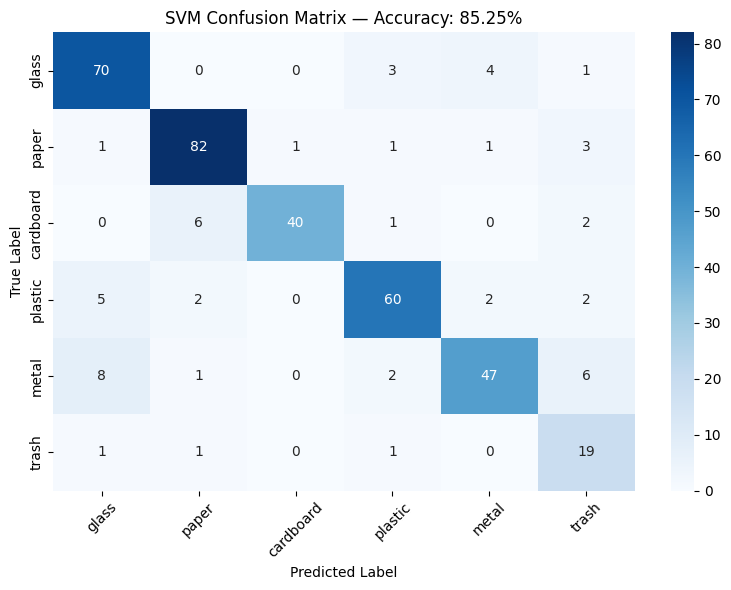

Saved: scaler.pkl | pca.pkl | svm_classifier.pkl


In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Training SVM...")
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_train_pca, y_train)
print("SVM training complete.")

y_pred_svm = svm.predict(X_val_pca)
acc_svm    = accuracy_score(y_val, y_pred_svm)

print(f"\nSVM Accuracy: {acc_svm*100:.2f}%")
print(classification_report(y_val, y_pred_svm, target_names=CLASS_NAMES))

cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'SVM Confusion Matrix — Accuracy: {acc_svm*100:.2f}%')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca,    'pca.pkl')
joblib.dump(svm,    'svm_classifier.pkl')
print("Saved: scaler.pkl | pca.pkl | svm_classifier.pkl")

Class weights: {'glass': np.float64(1.63), 'paper': np.float64(1.467), 'cardboard': np.float64(1.467), 'plastic': np.float64(1.222), 'metal': np.float64(1.571), 'trash': np.float64(1.528)}

Training SVM...
SVM training complete.

SVM Accuracy: 85.25%
              precision    recall  f1-score   support

       glass       0.82      0.90      0.86        78
       paper       0.89      0.92      0.91        89
   cardboard       0.98      0.82      0.89        49
     plastic       0.88      0.85      0.86        71
       metal       0.87      0.73      0.80        64
       trash       0.58      0.86      0.69        22

    accuracy                           0.85       373
   macro avg       0.84      0.85      0.83       373
weighted avg       0.86      0.85      0.85       373



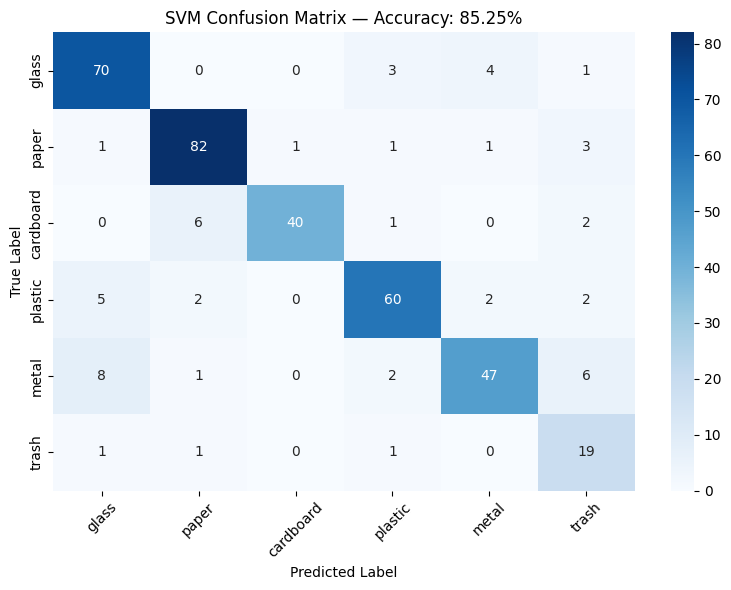

Saved: scaler.pkl | pca.pkl | svm_classifier.pkl


In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
class_weight_dict[0] *= 2.0
class_weight_dict[5] *= 2.5
class_weight_dict[4] *= 1.5

print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})

print("\nTraining SVM...")
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight=class_weight_dict,
    probability=True,
    random_state=42
)
svm.fit(X_train_pca, y_train)
print("SVM training complete.")

y_pred_svm = svm.predict(X_val_pca)
acc_svm    = accuracy_score(y_val, y_pred_svm)

print(f"\nSVM Accuracy: {acc_svm*100:.2f}%")
print(classification_report(y_val, y_pred_svm, target_names=CLASS_NAMES))

cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'SVM Confusion Matrix — Accuracy: {acc_svm*100:.2f}%')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca,    'pca.pkl')
joblib.dump(svm,    'svm_classifier.pkl')
print("Saved: scaler.pkl | pca.pkl | svm_classifier.pkl")

In [13]:
print(len(train_imgs))

4400


Training K-NN...
K-NN training complete.

K-NN Accuracy: 72.12%
              precision    recall  f1-score   support

       glass       0.60      0.79      0.69        78
       paper       0.85      0.75      0.80        89
   cardboard       0.79      0.76      0.77        49
     plastic       0.80      0.63      0.71        71
       metal       0.64      0.70      0.67        64
       trash       0.72      0.59      0.65        22

    accuracy                           0.72       373
   macro avg       0.73      0.71      0.71       373
weighted avg       0.74      0.72      0.72       373



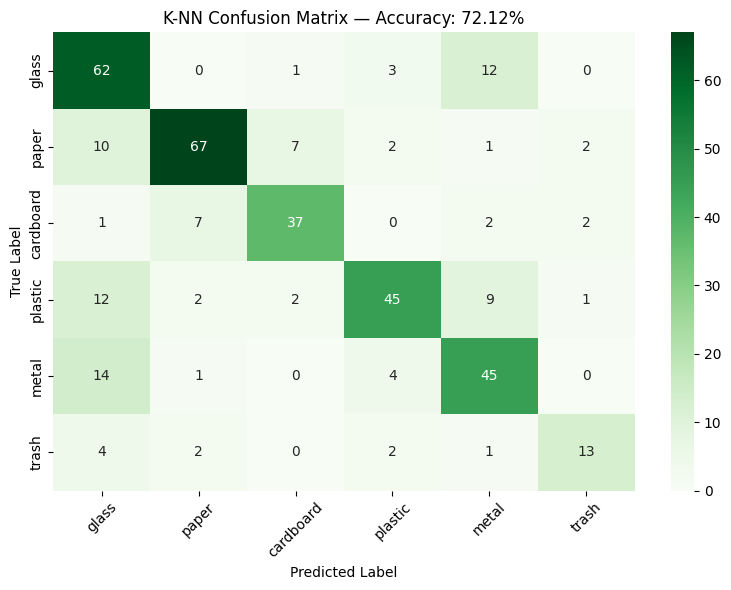

Saved: knn_classifier.pkl

  SVM Accuracy : 85.25%
  K-NN Accuracy: 72.12%
  Winner       : SVM


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

print("Training K-NN...")
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='cosine',
    weights='distance',
    n_jobs=-1
)
knn.fit(X_train_pca, y_train)
print("K-NN training complete.")

y_pred_knn = knn.predict(X_val_pca)
acc_knn    = accuracy_score(y_val, y_pred_knn)

print(f"\nK-NN Accuracy: {acc_knn*100:.2f}%")
print(classification_report(y_val, y_pred_knn, target_names=CLASS_NAMES))

cm = confusion_matrix(y_val, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'K-NN Confusion Matrix — Accuracy: {acc_knn*100:.2f}%')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150)
plt.show()

joblib.dump(knn, 'knn_classifier.pkl')
print("Saved: knn_classifier.pkl")

print("\n" + "="*40)
print(f"  SVM Accuracy : {acc_svm*100:.2f}%")
print(f"  K-NN Accuracy: {acc_knn*100:.2f}%")
print(f"  Winner       : {'SVM' if acc_svm >= acc_knn else 'K-NN'}")
print("="*40)

In [15]:
from google.colab import files

files.download('scaler.pkl')
files.download('pca.pkl')
files.download('svm_classifier.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>